In [6]:
import pandas as pd
import re
import plotly.express as px
from tqdm import tqdm
from joblib import Parallel, delayed
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch 
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("linkedin_jobs.csv")
df_test = df.tail().copy()
df_test

,Title,Company,Location,Link,Description,Responsibilities,QualificationsRequired,QualificationsPreferred,Requirements,Salary,EmploymentType,AboutTheCompany,WorkplaceType,Applicants,Posted_date
478,Analytics Specialist,Joni and Friends,"Agoura Hills, CA",https://www.linkedin.com/jobs/view/4296699675/...,Duties:\n\nUnder the supervision of the Data B...,['Under the supervision of the Data Batching T...,['Must possess a vibrant personal relationship...,[],[],$22.00 per hour,Full Time,"Joni and Friends\n7,510 followers\nFollow\nNon...",Hybrid,4 applicants,NaN
479,Senior Fullstack Developer (Java/Python/React)...,Synergy Interactive,"Irvine, CA",https://www.linkedin.com/jobs/view/4297573443/...,We are looking for a highly skilled Senior Ful...,[],['Bachelor’s or Master’s degree in Computer Sc...,[],[],$60/hr,Intern,"Synergy Interactive\n525,439 followers\nFollow...",Hybrid,Over 100 applicants,2025/09/09
480,Technical Support Analyst,Winter Park Recruiting,"Orlando, FL",https://www.linkedin.com/jobs/view/4294491217/...,Winter Park Recruiting is a leading recruitmen...,[],"[""performing teams. We believe in personalized...",[],[],$60K/yr,Intern,"Winter Park Recruiting\n4,085 followers\nFollo...",Remote,Over 100 applicants,2025/09/06
481,Enterprise Account Executive,RevPilots,NaN,https://www.linkedin.com/jobs/view/4297244796/...,(This is for a RevPilots' client)\n\nAccount E...,[],"['Required:', ""Bachelor's degree in Business (...","[""Master's degree in a technical or business d...",[],"Salary: $150,000",Full Time,"RevPilots\n25,058 followers\nFollow\nTechnolog...",Remote,NaN,NaN
482,Technical Artist,Bluberi,NaN,https://www.linkedin.com/jobs/view/4296348241/...,BLUBERI VALUES: \nWe Are the New School \nClar...,[],['talented innovators who are focused on bring...,[],[],$40/hr,Full Time,"Bluberi\n11,925 followers\nFollow\nGambling Fa...",Remote,NaN,NaN


## Salary

In [4]:
import re
import pandas as pd
import numpy as np

def parse_salary(s):
    """
    Parse salary string into an estimated annual salary (numeric).
    Handles hourly, weekly, monthly, yearly, and ranges.
    Assumptions:
    - Hourly: 40 hrs/week, 52 weeks/year
    - Weekly: 52 weeks/year
    - Monthly: 12 months/year
    """
    if not isinstance(s, str) or not s.strip():
        return np.nan
    
    s = s.lower().replace(",", "").strip()

    # Extract numbers (with optional K or M)
    nums = re.findall(r"\$?\d+(?:\.\d+)?[kKmM]?", s)
    if not nums:
        return np.nan
    
    # Convert numbers into floats
    values = []
    for n in nums:
        n = n.replace("$", "")
        if "k" in n:
            values.append(float(n[:-1]) * 1000)
        elif "m" in n:
            values.append(float(n[:-1]) * 1_000_000)
        else:
            values.append(float(n))
    
    # If it's a range, take the average
    val = sum(values) / len(values)

    # Detect time unit
    if re.search(r"/?\s*hour|/hr", s):
        val *= 40 * 52
    elif re.search(r"/?\s*week|/wk", s):
        val *= 52
    elif re.search(r"/?\s*month|/mo", s):
        val *= 12
    elif re.search(r"/?\s*year|/yr|/y", s):
        pass  # already annual
    else:
        # No explicit unit → assume yearly
        pass

    return val

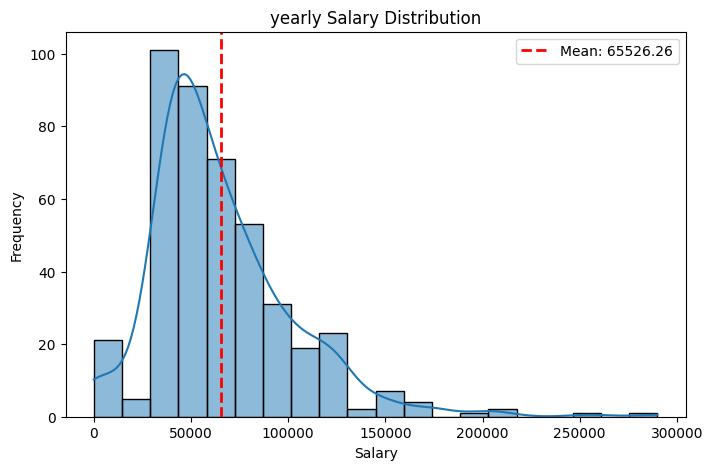

In [15]:
df["Salary"] = df["Salary"].apply(parse_salary)

plt.figure(figsize=(8, 5))
sns.histplot(df["Salary"], bins=20, kde=True)
plt.axvline(salary_mean, color='red', linestyle='dashed', linewidth=2, label=f"Mean: {salary_mean:.2f}")
plt.title("yearly Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Seniority

In [16]:
def normalize_title(title):
    """
    Normalize job title into a standard seniority level.
    """
    if not isinstance(title, str):
        return "Entry"  # default
    
    t = title.lower().strip()

    # Intern detection
    if "intern" in t or "internship" in t:
        return "Intern"

    # Explicit senior/leadership keywords
    if "principal" in t or "staff" in t or "lead" in t or "architect" in t:
        return "Lead/Principal"
    if "manager" in t or "director" in t or "vp" in t or "head of" in t:
        return "Management"
    if "senior" in t:
        return "Senior"

    # Roman numerals / levels
    if re.search(r"\b(i{3}|iii)\b", t):  
        return "Senior"
    if re.search(r"\b(ii)\b", t):        
        return "Mid"
    if re.search(r"\b(i)\b", t):        
        return "Entry"

    # Default assumption 
    return "Entry"

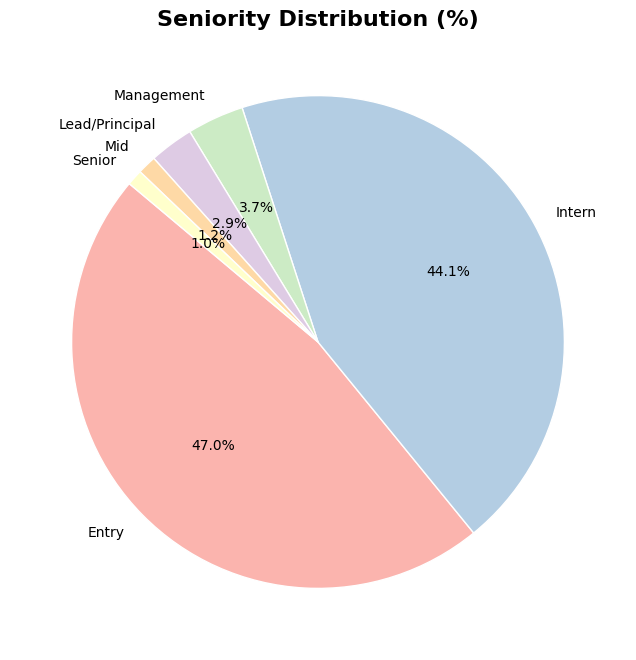

In [20]:
df["seniority"] = df["Title"].apply(normalize_title)

seniority_counts = df["seniority"].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 8))
plt.pie(
    seniority_counts,
    labels=seniority_counts.index,
    autopct="%.1f%%",       
    startangle=140,         
    colors=plt.cm.Pastel1.colors, 
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)
plt.title("Seniority Distribution (%)", fontsize=16, fontweight="bold")
plt.show()

## Domain

In [21]:
Model_ID = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(Model_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    Model_ID,
    dtype=torch.float16,   
    device_map="auto"
)

Loading checkpoint shards: 100%|██████████| 4/4 [00:07<00:00,  1.78s/it]


In [46]:
def generate_domains_batched(df, title_column="Title", batch_size=16, max_new_tokens=15):
    all_domains = []

    for i in tqdm(range(0, len(df), batch_size), desc="Batch extracting domains"):
        batch_df = df.iloc[i:i + batch_size]

        prompts = [
            f"""
            You are a helpful assistant to figure out the job categories. 
            Extract the corresponding domain from job title.
            Please return the meaningful domain. The format should be words, no punctuation and special characters please. 
            And no explanations Thank you.

            Title: "{title}"
            Domain:
            """
            for title in batch_df[title_column]
        ]

        encodings = tokenizer(
            prompts, return_tensors="pt", padding=True, truncation=True, max_length=1024
        )
        input_ids = encodings["input_ids"].to(model.device)
        attention_mask = encodings["attention_mask"].to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=0.0,
                pad_token_id=tokenizer.pad_token_id
            )

        for j in range(outputs.shape[0]):
            gen_tokens = outputs[j][input_ids.shape[1]:] 
            text = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()
            domain = text.split("\n")[0].strip()
            all_domains.append(domain)

    assert len(all_domains) == len(df), f"Expected {len(df)} results, got {len(all_domains)}"
    return all_domains

In [47]:
df["Job Category"] = generate_domains_batched(df, title_column="Title")

Batch extracting domains: 100%|██████████| 31/31 [00:27<00:00,  1.14it/s]


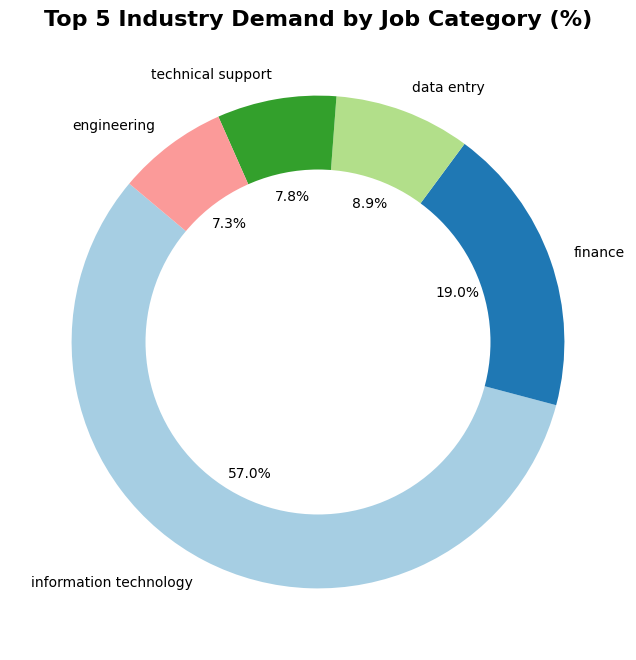

In [51]:
df["Job Category"].replace("it", "information technology", inplace=True)
category_counts = df["Job Category"].value_counts().nlargest(5)
category_percentages = (category_counts / category_counts.sum()) * 100

# Plot
plt.figure(figsize=(8, 8))
plt.pie(
    category_percentages,
    labels=category_percentages.index,
    autopct="%.1f%%",
    startangle=140,
    colors=plt.cm.Paired.colors
)

# Donut style
centre_circle = plt.Circle((0, 0), 0.70, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Top 5 Industry Demand by Job Category (%)", fontsize=16, fontweight="bold")
plt.show()

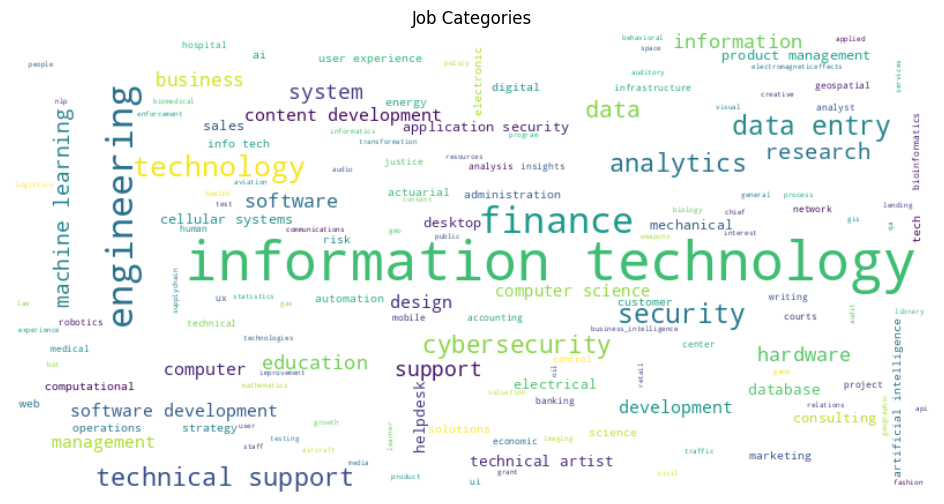

In [65]:
from wordcloud import WordCloud

text = " ".join(df["Job Category"].dropna().astype(str))

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis" 
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Job Categories")
plt.show()

## Location and Time

In [53]:
US_STATE_MAP = {
    "Alabama": "AL","Alaska": "AK","Arizona": "AZ","Arkansas": "AR","California": "CA",
    "Colorado": "CO","Connecticut": "CT","Delaware": "DE","Florida": "FL","Georgia": "GA",
    "Hawaii": "HI","Idaho": "ID","Illinois": "IL","Indiana": "IN","Iowa": "IA",
    "Kansas": "KS","Kentucky": "KY","Louisiana": "LA","Maine": "ME","Maryland": "MD",
    "Massachusetts": "MA","Michigan": "MI","Minnesota": "MN","Mississippi": "MS",
    "Missouri": "MO","Montana": "MT","Nebraska": "NE","Nevada": "NV","New Hampshire": "NH",
    "New Jersey": "NJ","New Mexico": "NM","New York": "NY","North Carolina": "NC",
    "North Dakota": "ND","Ohio": "OH","Oklahoma": "OK","Oregon": "OR","Pennsylvania": "PA",
    "Rhode Island": "RI","South Carolina": "SC","South Dakota": "SD","Tennessee": "TN",
    "Texas": "TX","Utah": "UT","Vermont": "VT","Virginia": "VA","Washington": "WA",
    "West Virginia": "WV","Wisconsin": "WI","Wyoming": "WY",
    "District of Columbia": "DC","DC": "DC"
}

def city_state_country_from_location(df):
    df[["city", "state", "country"]] = None

    split_cols = df["Location"].str.split(",", n=2, expand=True)

    for i, row in split_cols.iterrows():
        parts = [p.strip() for p in row if isinstance(p, str) and p.strip()]

        if len(parts) == 1:
            val = parts[0]
            if val.upper() in US_STATE_MAP.values():
                df.at[i, "state"] = val.upper()
            elif val in US_STATE_MAP:
                df.at[i, "state"] = US_STATE_MAP[val]
            elif val.lower() in ("united states", "usa", "u.s."):
                df.at[i, "country"] = "United States"
            else:
                df.at[i, "city"] = val

        elif len(parts) == 2:
            # Case: City, State
            if parts[1].upper() in US_STATE_MAP.values():
                df.at[i, "city"], df.at[i, "state"] = parts[0], parts[1].upper()
            elif parts[1] in US_STATE_MAP:
                df.at[i, "city"], df.at[i, "state"] = parts[0], US_STATE_MAP[parts[1]]
            elif parts[1].lower() in ("united states", "usa", "u.s."):
                df.at[i, "state"], df.at[i, "country"] = parts[0], "United States"
            else:
                df.at[i, "city"], df.at[i, "state"] = parts

        elif len(parts) == 3:
            city, state, country = parts[0], parts[1], parts[2]

            # Normalize state
            if state.upper() in US_STATE_MAP.values():
                state = state.upper()
            elif state in US_STATE_MAP:
                state = US_STATE_MAP[state]
            else:
                # handle "Metropolitan Area"
                state_clean = re.sub(r"\s+Metropolitan Area$", "", state).strip()
                if state_clean in US_STATE_MAP:
                    state = US_STATE_MAP[state_clean]

            df.at[i, "city"], df.at[i, "state"], df.at[i, "country"] = city, state, country

    return df

def normalize_us_state(val):
    if not isinstance(val, str) or not val.strip():
        return None
    v = val.strip()

    # Already 2-letter code
    if v.upper() in US_STATE_MAP.values():
        return v.upper()

    # Full state name
    if v in US_STATE_MAP:
        return US_STATE_MAP[v]

    # Handle "Metropolitan Area"
    v_clean = re.sub(r"\s+Metropolitan Area$", "", v).strip()
    if v_clean in US_STATE_MAP:
        return US_STATE_MAP[v_clean]

    return None

In [54]:
df = city_state_country_from_location(df)
df["state"] = df["state"].apply(normalize_us_state)
df["state"].unique()

array([None, 'FL', 'TX', 'CO', 'NM', 'NY', 'CA', 'IL', 'NJ', 'WA', 'MI',
       'OK', 'WI', 'AZ', 'NC', 'MA', 'GA', 'DC', 'KS', 'VA', 'AR', 'MO',
       'IA', 'MN', 'PA', 'IN', 'UT', 'SC', 'OR', 'OH', 'NV', 'NE', 'MD',
       'KY', 'DE', 'TN', 'ND', 'WY'], dtype=object)

In [62]:
df["Posted_date"] = pd.to_datetime(df["Posted_date"], errors="coerce")
df["month"] = df["Posted_date"].dt.to_period("M")
df["month"] = df["month"].ffill().bfill()
job_counts = (
    df.dropna(subset=["state"])  
      .groupby(["month", "state"])
      .size()
      .reset_index(name="job_count")
      .sort_values(["month", "state"])
)

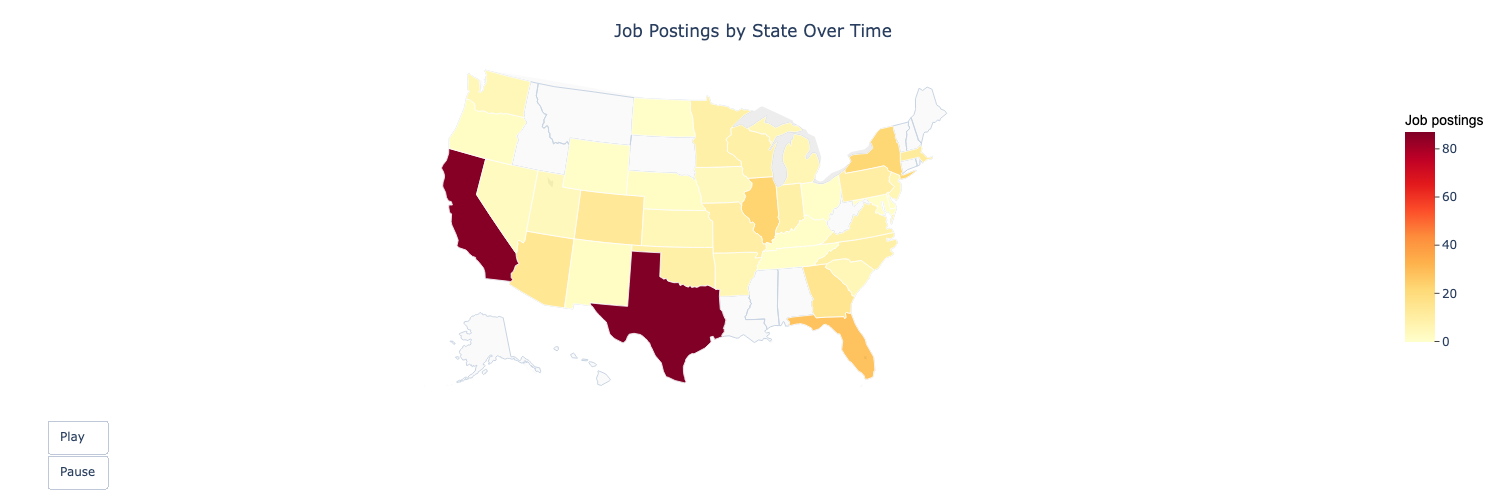

In [72]:
vmin = 0
vmax = np.nanmax(job_counts["job_count"].values)

fig = px.choropleth(
    job_counts,                 
    locations="state",           
    locationmode="USA-states",   
    color="job_count",         
    hover_name="state",          
    animation_frame="month",
    range_color=(vmin, vmax),
    color_continuous_scale="YlOrRd",
    labels={"job_count": "Job postings"},
    scope="usa"   # <-- added missing comma above
)

fig.update_traces(
    marker_line_color="white",
    marker_line_width=0.8,
    hovertemplate="<b>%{hovertext}</b><br>" +
                  "Month: %{animation_group}<br>" +
                  "Jobs: %{z:,}<extra></extra>"
)

fig.update_layout(
    title={
        "text": "Job Postings by State Over Time",
        "x": 0.5,
        "xanchor": "center",
        "y": 0.95
    },
    template="plotly_white",
    geo=dict(
        scope="usa",
        showlakes=True, lakecolor="rgba(0,0,0,0.05)",
        showcountries=False,
        showland=True, landcolor="rgba(0,0,0,0.02)"
    ),
    coloraxis_colorbar=dict(
    title=dict(text="Job postings", font=dict(size=14, family="Arial", color="black")),
    ticks="outside",
    tickformat=",",
    lenmode="fraction",
    len=0.75
)
,

    updatemenus=[{
        "type": "buttons",
        "showactive": False,
        "buttons": [
            {
                "label": "Play",
                "method": "animate",
                "args": [None, {"frame": {"duration": 700, "redraw": True},
                                "fromcurrent": True, "transition": {"duration": 300}}]
            },
            {
                "label": "Pause",
                "method": "animate",
                "args": [[None], {"frame": {"duration": 0, "redraw": False},
                                  "mode": "immediate",
                                  "transition": {"duration": 0}}]
            }
        ],
        "x": 0.02, "y": -0.08, "xanchor": "left", "yanchor": "top"
    }],
    sliders=[{
        "pad": {"t": 40},
        "currentvalue": {"prefix": "Month: "},
        "len": 0.9
    }]
)

fig.update_layout(
    width=800,     
    height=500,    
    margin=dict(l=20, r=20, t=60, b=20)  
)


fig.layout.sliders[0].steps = sorted(fig.layout.sliders[0].steps, key=lambda s: s["label"])

fig.show()


## Employeement Type

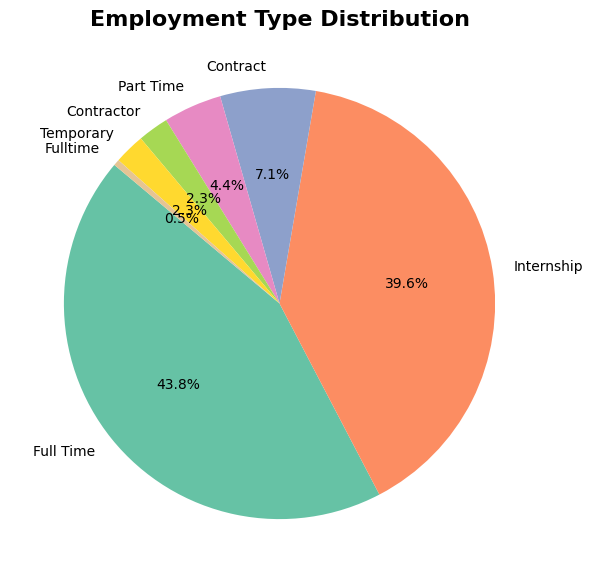

In [76]:
df["EmploymentType"] = df["EmploymentType"].replace({
    "Intern": "Internship"
})
emp_counts = df["EmploymentType"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    emp_counts,
    labels=emp_counts.index,
    autopct="%.1f%%",
    startangle=140,
    colors=plt.cm.Set2.colors
)
plt.title("Employment Type Distribution", fontsize=16, fontweight="bold")
plt.show()